# Initial Exploratory Data Analysis (ID-SMSA Dataset)

In [25]:
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
colors = ["#2ecc71", "#95a5a6", "#e74c3c"]
sns.set_palette(colors)
plt.rcParams["figure.figsize"] = (10, 6)

### 1. Data Loading & Overview

In [26]:
df = pd.read_csv("../data/raw/IDSMSA.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3288 entries, 0 to 3287
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Tweet Date           3288 non-null   str  
 1   Sentence             3288 non-null   str  
 2   Quote Count          3288 non-null   int64
 3   Reply Count          3288 non-null   int64
 4   Retweet Count        3288 non-null   int64
 5   Favorite Count       3288 non-null   int64
 6   Sentiment            3288 non-null   str  
 7   English Translation  3288 non-null   str  
dtypes: int64(4), str(4)
memory usage: 1.2 MB


In [27]:
df.head()

,Tweet Date,Sentence,Quote Count,Reply Count,Retweet Count,Favorite Count,Sentiment,English Translation
0,Thu Feb 29 11:21:27 +0000 2024,"Gk muluk muluk, 100,000 lot saham BBCA aja",0,0,0,0,Positive,"Not too ambitious, just 100,000 lots of BBCA s..."
1,Thu Feb 29 10:11:05 +0000 2024,BCA Expoversary 2024 menawarkan promo suku bun...,0,0,0,0,Neutral,BCA Expoversary 2024 offers special interest r...
2,Thu Feb 29 10:06:04 +0000 2024,[USERNAME] saham bca nya menyusul ya 🙂,0,0,0,0,Positive,[USERNAME] BCA shares will follow 🙂
3,Thu Feb 29 07:42:09 +0000 2024,PT Bank BCA Syariah (BCA Syariah) turut memeri...,0,0,0,0,Neutral,PT Bank BCA Syariah (BCA Syariah) also enliven...
4,Thu Feb 29 06:06:17 +0000 2024,[USERNAME] Begitu byk saham kamu memilih saham...,0,0,0,1,Positive,[USERNAME] So many stocks you choose those sto...


In [28]:
pd.DataFrame(
    {
        "Missing Values": df.isnull().sum(),
        "Data Type": df.dtypes,
        "Unique Count": df.nunique(),
    }
)

,Missing Values,Data Type,Unique Count
Tweet Date,0,str,3263
Sentence,0,str,3254
Quote Count,0,int64,23
Reply Count,0,int64,41
Retweet Count,0,int64,40
Favorite Count,0,int64,88
Sentiment,0,str,3
English Translation,0,str,3251


### 2. Sentiment Class Distribution

In [29]:
sentiment_summary = pd.DataFrame(
    {
        "Count": df["Sentiment"].value_counts(),
        "Percentage (%)": (df["Sentiment"].value_counts(normalize=True) * 100).round(2),
    }
)
sentiment_summary

,Count,Percentage (%)
Sentiment,,
Positive,1769,53.80
Negative,786,23.91
Neutral,733,22.29


C:\Users\sulto\AppData\Local\Temp\ipykernel_28844\2103071450.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_summary.index, y=sentiment_summary["Count"], ax=axes[0], palette=colors)


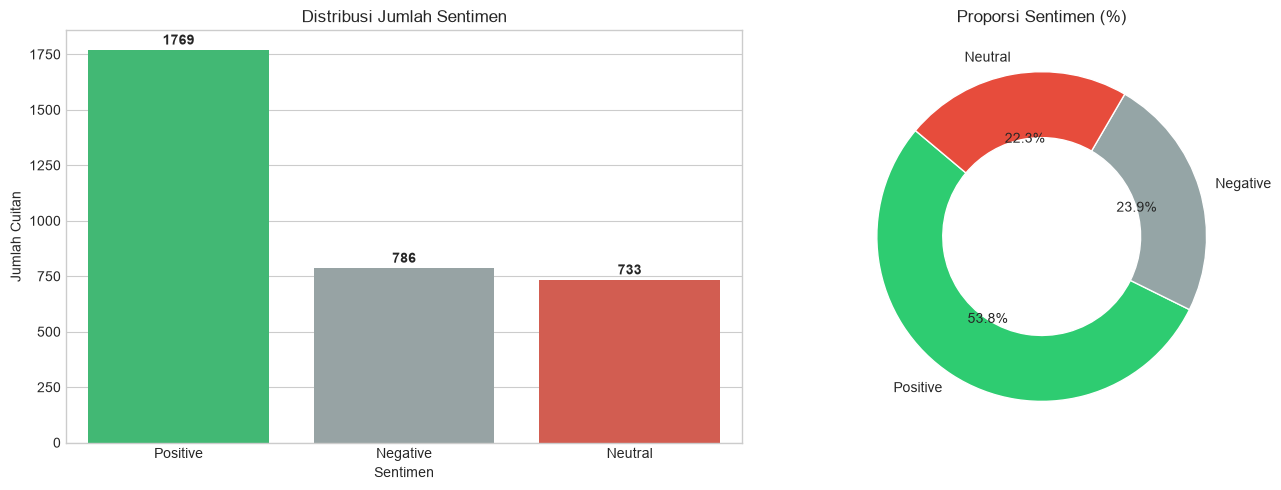

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=sentiment_summary.index, y=sentiment_summary["Count"], ax=axes[0], palette=colors)
axes[0].set_title("Distribusi Jumlah Sentimen")
axes[0].set_xlabel("Sentimen")
axes[0].set_ylabel("Jumlah Cuitan")
for i, v in enumerate(sentiment_summary["Count"]):
    axes[0].text(i, v + 25, f"{v}", ha="center", fontweight="bold")

axes[1].pie(
    sentiment_summary["Count"],
    labels=sentiment_summary.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=140,
    wedgeprops=dict(width=0.4, edgecolor="w"),
)
axes[1].set_title("Proporsi Sentimen (%)")

plt.tight_layout()
plt.show()

### 3. Text Length Distribution

In [31]:
df["char_length"] = df["Sentence"].astype(str).apply(len)
df["word_count"] = df["Sentence"].astype(str).apply(lambda x: len(x.split()))
df[["char_length", "word_count"]].describe().round(2)

,char_length,word_count
count,3288.00,3288.00
mean,135.22,20.89
std,81.09,11.96
min,6.00,1.00
25%,70.00,11.00
50%,103.00,16.00
75%,201.00,30.00
max,407.00,56.00


C:\Users\sulto\AppData\Local\Temp\ipykernel_28844\2311510380.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Sentiment", y="word_count", ax=axes[1], palette=colors)


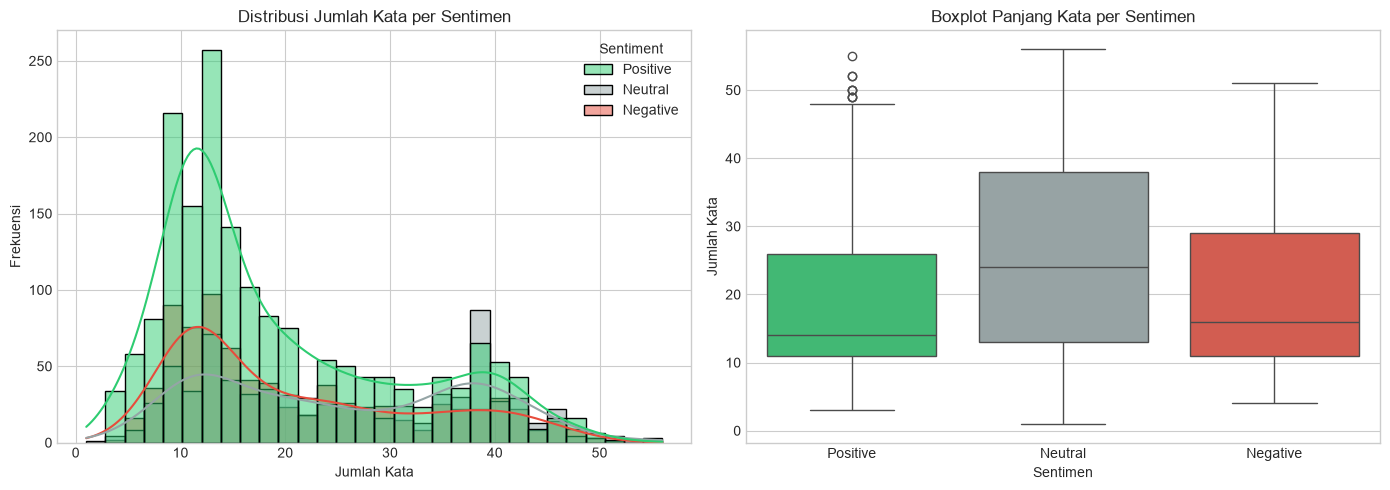

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="word_count", hue="Sentiment", bins=30, kde=True, ax=axes[0], palette=colors)
axes[0].set_title("Distribusi Jumlah Kata per Sentimen")
axes[0].set_xlabel("Jumlah Kata")
axes[0].set_ylabel("Frekuensi")

sns.boxplot(data=df, x="Sentiment", y="word_count", ax=axes[1], palette=colors)
axes[1].set_title("Boxplot Panjang Kata per Sentimen")
axes[1].set_xlabel("Sentimen")
axes[1].set_ylabel("Jumlah Kata")

plt.tight_layout()
plt.show()

### 4. Stock Ticker Mentions (10 Big Cap)

In [33]:
target_stocks = ["BBCA", "BBRI", "BMRI", "BBNI", "TLKM", "ASII", "UNVR", "TPIA", "HMSP", "BYAN"]


def detect_stocks(text):
    text_upper = str(text).upper()
    found = []
    for stock in target_stocks:
        patterns = [rf"\b{stock}\b"]
        if stock == "BBCA":
            patterns.append(r"\bBCA\b")
        elif stock == "BBRI":
            patterns.append(r"\bBRI\b")
        elif stock == "BMRI":
            patterns.append(r"\bMANDIRI\b")
        elif stock == "BBNI":
            patterns.append(r"\bBNI\b")
        elif stock == "TLKM":
            patterns.append(r"\bTELKOM\b")
        elif stock == "ASII":
            patterns.append(r"\bASTRA\b")
        elif stock == "UNVR":
            patterns.append(r"\bUNILEVER\b")

        if any(re.search(p, text_upper) for p in patterns):
            found.append(stock)
    return found if found else ["OTHERS"]


df["mentioned_stocks"] = df["Sentence"].apply(detect_stocks)
df_stocks_exploded = df.explode("mentioned_stocks").reset_index(drop=True)

stock_table = (
    df_stocks_exploded[df_stocks_exploded["mentioned_stocks"].isin(target_stocks)]["mentioned_stocks"]
    .value_counts()
    .reset_index()
)
stock_table.columns = ["Stock Ticker", "Mention Count"]
stock_table

,Stock Ticker,Mention Count
0,BBCA,581
1,BBRI,572
2,BMRI,436
3,UNVR,419
4,ASII,418
5,BYAN,386
6,HMSP,386
7,BBNI,379
8,TPIA,335
9,TLKM,334


C:\Users\sulto\AppData\Local\Temp\ipykernel_28844\1789250907.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stock_table, x="Stock Ticker", y="Mention Count", palette="viridis")


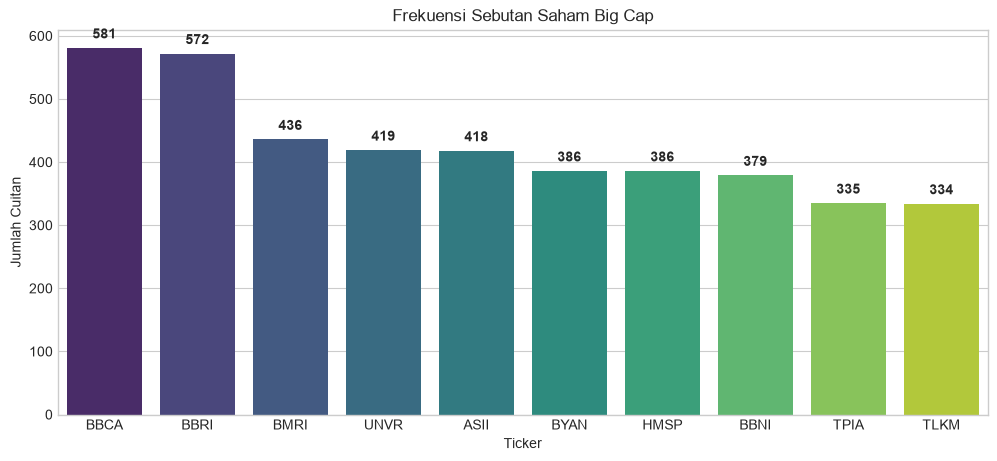

In [34]:
plt.figure(figsize=(12, 5))
sns.barplot(data=stock_table, x="Stock Ticker", y="Mention Count", palette="viridis")
plt.title("Frekuensi Sebutan Saham Big Cap")
plt.xlabel("Ticker")
plt.ylabel("Jumlah Cuitan")
for i, v in enumerate(stock_table["Mention Count"]):
    plt.text(i, v + 15, str(v), ha="center", fontweight="bold")
plt.show()

In [35]:
df_filtered_stocks = df_stocks_exploded[df_stocks_exploded["mentioned_stocks"].isin(target_stocks)].reset_index(
    drop=True
)
stock_sentiment_ct = pd.crosstab(
    df_filtered_stocks["mentioned_stocks"],
    df_filtered_stocks["Sentiment"],
    normalize="index",
) * 100
stock_sentiment_ct.round(2)

Sentiment,Negative,Neutral,Positive
mentioned_stocks,,,
ASII,34.93,24.40,40.67
BBCA,13.25,22.89,63.86
BBNI,10.03,24.01,65.96
BBRI,9.79,19.41,70.80
BMRI,10.55,16.06,73.39
BYAN,19.69,25.13,55.18
HMSP,37.56,24.35,38.08
TLKM,23.65,21.26,55.09
TPIA,22.99,24.18,52.84


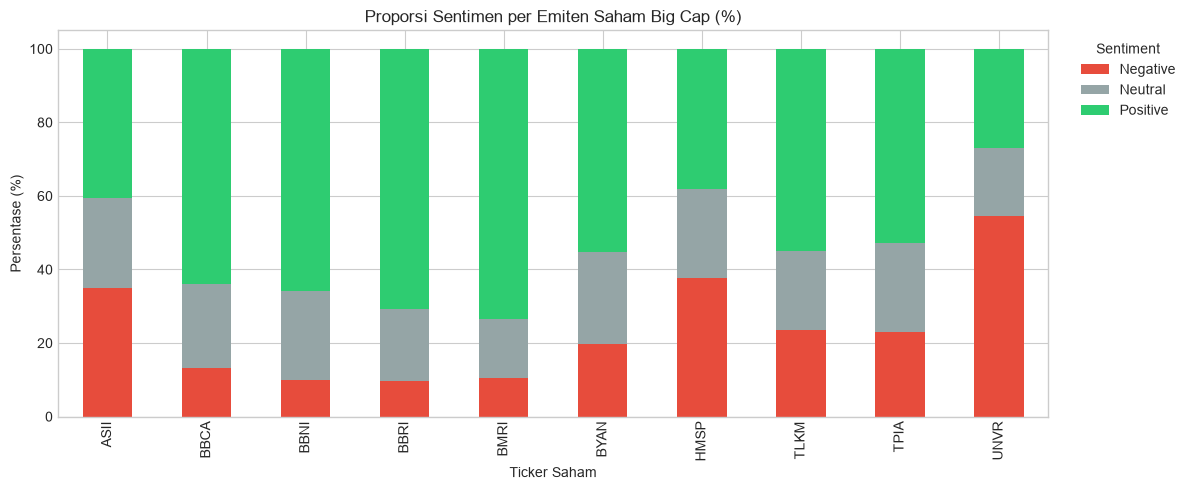

In [36]:
stock_sentiment_ct.plot(
    kind="bar",
    stacked=True,
    color=["#e74c3c", "#95a5a6", "#2ecc71"],
    figsize=(12, 5),
)
plt.title("Proporsi Sentimen per Emiten Saham Big Cap (%)")
plt.xlabel("Ticker Saham")
plt.ylabel("Persentase (%)")
plt.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 5. Engagement Metrics

In [37]:
engagement_cols = ["Quote Count", "Reply Count", "Retweet Count", "Favorite Count"]
df.groupby("Sentiment")[engagement_cols].agg(["mean", "median", "max"]).round(2)

Quote Count             Reply Count             Retweet Count  \
                 mean median  max        mean median  max          mean   
Sentiment                                                                 
Negative         0.82    0.0  366        1.76    0.0  343          2.94   
Neutral          0.14    0.0   15        1.28    0.0   40          0.49   
Positive         0.27    0.0  112        0.76    0.0  209          0.86   

                       Favorite Count               
          median   max           mean median   max  
Sentiment                                           
Negative     0.0  1413          13.62    0.0  6318  
Neutral      0.0    64           3.03    0.0   283  
Positive     0.0   340           6.01    0.0  4066

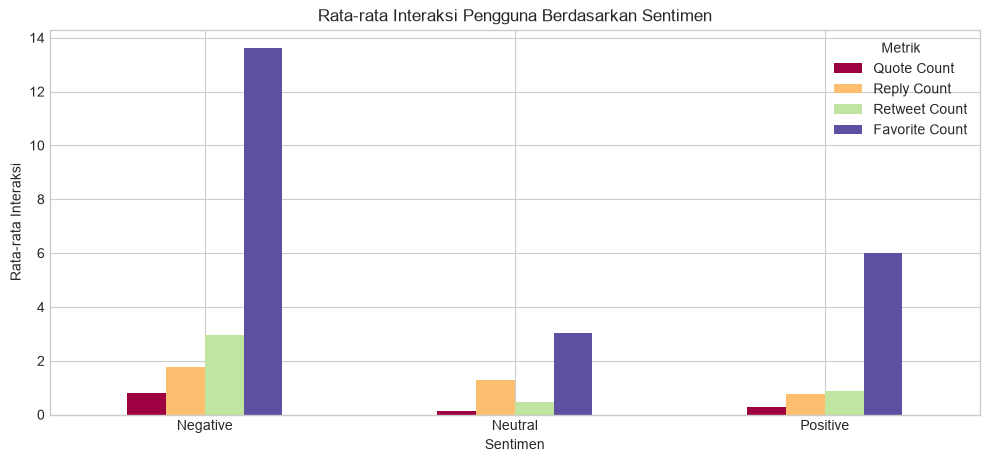

In [ ]:
avg_eng = df.groupby("Sentiment")[engagement_cols].mean()
avg_eng.plot(kind="bar", figsize=(12, 5), colormap="Spectral")
plt.title("Rata-rata Interaksi Pengguna Berdasarkan Sentimen")
plt.xlabel("Sentimen")
plt.ylabel("Rata-rata Interaksi")
plt.xticks(rotation=0)
plt.legend(title="Metrik")
plt.show()

### 6. Temporal Analysis

In [39]:
df["datetime"] = pd.to_datetime(df["Tweet Date"], errors="coerce")
df["year_month"] = df["datetime"].dt.to_period("M")
temporal_counts = df.groupby(["year_month", "Sentiment"]).size().unstack(fill_value=0)
temporal_counts.tail(12)

C:\Users\sulto\AppData\Local\Temp\ipykernel_28844\2286526853.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["datetime"] = pd.to_datetime(df["Tweet Date"], errors="coerce")
C:\Users\sulto\AppData\Local\Temp\ipykernel_28844\2286526853.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["year_month"] = df["datetime"].dt.to_period("M")


Sentiment,Negative,Neutral,Positive
year_month,,,
2023-04,17,11,23
2023-05,22,15,24
2023-06,15,19,41
2023-07,20,22,40
2023-08,30,28,38
2023-09,21,17,42
2023-10,72,88,127
2023-11,59,46,148
2023-12,46,83,264


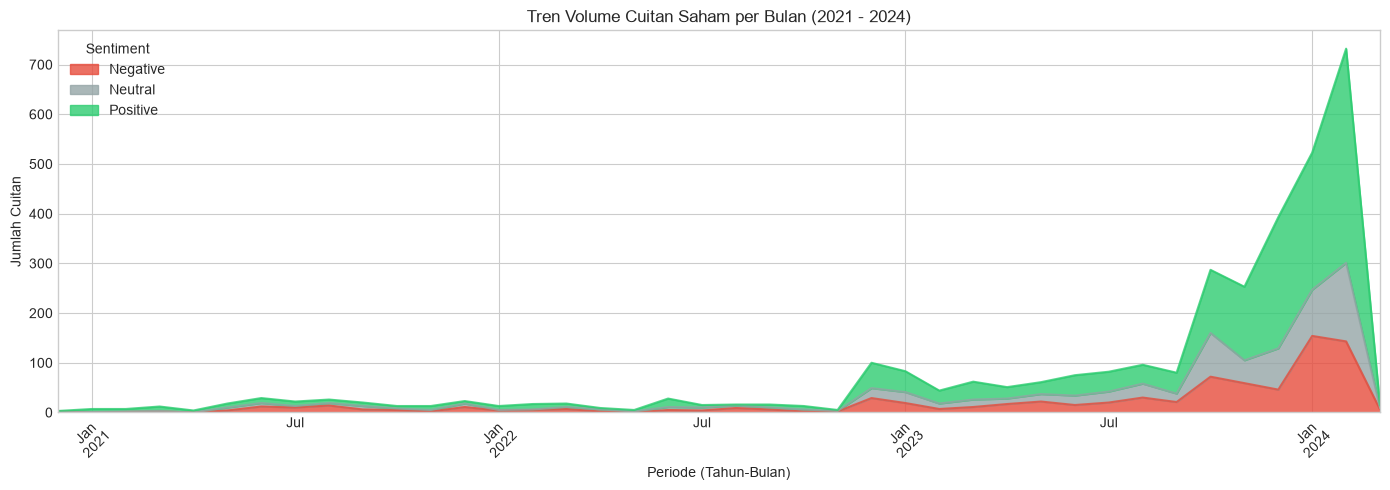

In [40]:
temporal_counts.plot(kind="area", stacked=True, color=["#e74c3c", "#95a5a6", "#2ecc71"], figsize=(14, 5), alpha=0.8)
plt.title("Tren Volume Cuitan Saham per Bulan (2021 - 2024)")
plt.xlabel("Periode (Tahun-Bulan)")
plt.ylabel("Jumlah Cuitan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 7. Financial Slang / Keywords Frequency

In [41]:
stock_slang = [
    "cuan",
    "cut loss",
    "ara",
    "arb",
    "ath",
    "dividen",
    "lot",
    "hold",
    "serok",
    "nyangkut",
    "ihsg",
    "bandar",
    "fomo",
    "bearish",
    "bullish",
]

slang_presence = {}
for slang in stock_slang:
    count = df["Sentence"].str.lower().str.contains(rf"\b{slang}\b").sum()
    slang_presence[slang] = count

df_slang = pd.DataFrame(list(slang_presence.items()), columns=["Istilah", "Frekuensi"]).sort_values(
    by="Frekuensi", ascending=False
)
df_slang.reset_index(drop=True)

,Istilah,Frekuensi
0,ihsg,516
1,dividen,194
2,cuan,172
3,lot,98
4,hold,50
5,ath,31
6,serok,25
7,nyangkut,21
8,bullish,14
9,arb,11


C:\Users\sulto\AppData\Local\Temp\ipykernel_28844\123406694.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_slang, x="Istilah", y="Frekuensi", palette="magma")


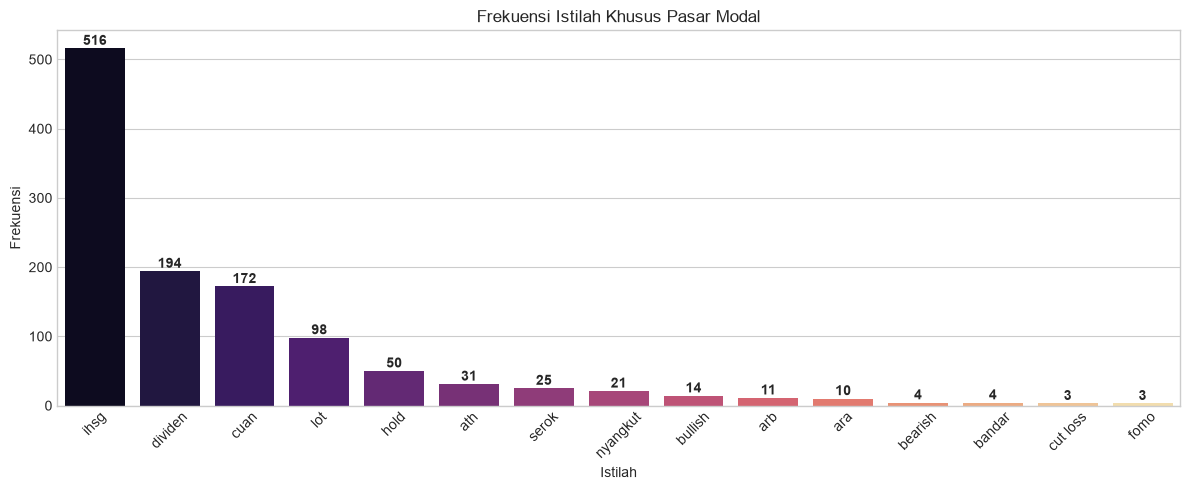

In [42]:
plt.figure(figsize=(12, 5))
sns.barplot(data=df_slang, x="Istilah", y="Frekuensi", palette="magma")
plt.title("Frekuensi Istilah Khusus Pasar Modal")
plt.xlabel("Istilah")
plt.ylabel("Frekuensi")
plt.xticks(rotation=45)
for i, v in enumerate(df_slang["Frekuensi"]):
    if v > 0:
        plt.text(i, v + 5, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()